In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random as rnd

In [2]:
(train_images, train_labels), (images, labels) = mnist.load_data()

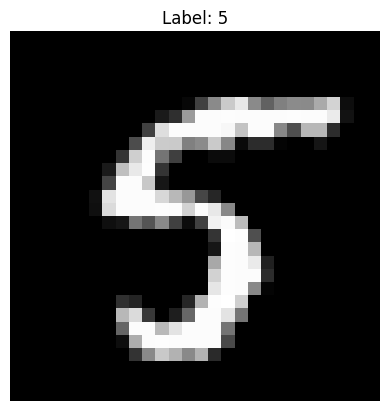

In [3]:
index = np.random.randint(0, images.shape[0])
image = images[index]
label = labels[index]

# Display it
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# Feature identification methods

Lots of features to identfy numbers. What features are used how much are determined by their weights.
Some features where written with ChatGTP to test te effect of adding extra features, these are at the bottom.

In [4]:
def check_center(image):
    center_size = 8
    start = (image.shape[0] - center_size) // 2
    end = start + center_size
    center_square = image[start:end, start:end]
    score = center_square.mean() / 255.0
    return score

def vertical_symmetry(image):
    flipped = np.fliplr(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def horizontal_symmetry(image):
    flipped = np.flipud(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def top_bottom_balance(image):
    mid = image.shape[0] // 2
    top = image[:mid, :].mean()
    bottom = image[mid:, :].mean()
    return (top - bottom) / 255.0

def pixel_density(image):
    return image.mean() / 255.0

def left_right_balance(image):
    mid = image.shape[1] // 2
    left = image[:, :mid].mean()
    right = image[:, mid:].mean()
    return (left - right) / 255.0

def active_pixels(image):
    return np.sum(image > 50) / (28 * 28)

#region More features written by ChatGPT
def center_of_mass_offset(image):
    coords = np.indices(image.shape)
    total = image.sum() + 1e-6
    cy = (coords[0] * image).sum() / total
    cx = (coords[1] * image).sum() / total

    center_y = image.shape[0] / 2
    center_x = image.shape[1] / 2

    dist = np.sqrt((cy - center_y)**2 + (cx - center_x)**2)
    return dist / (np.sqrt(2) * image.shape[0])

def horizontal_spread(image):
    col_sum = image.sum(axis=0)
    active = np.where(col_sum > 0)[0]
    if len(active) == 0:
        return 0
    width = active[-1] - active[0]
    return width / image.shape[1]

def vertical_spread(image):
    row_sum = image.sum(axis=1)
    active = np.where(row_sum > 0)[0]
    if len(active) == 0:
        return 0
    height = active[-1] - active[0]
    return height / image.shape[0]

def edge_density(image):
    gx = np.abs(np.diff(image, axis=1))
    gy = np.abs(np.diff(image, axis=0))
    edges = gx.mean() + gy.mean()
    return edges / 255.0

def stroke_thickness(image):
    binary = image > 50
    vertical_runs = np.sum(binary, axis=0)
    return vertical_runs.mean() / image.shape[0]

def connected_components(image):
    return 1


def orientation_bias(image):
    gx = np.diff(image, axis=1)
    gy = np.diff(image, axis=0)

    gx = gx[:-1, :]
    gy = gy[:, :-1]

    angle = np.arctan2(gy, gx)
    return np.mean(np.cos(2 * angle))

def diagonal_balance(image):
    diag1 = np.mean(np.diag(image))
    diag2 = np.mean(np.diag(np.fliplr(image)))
    return (diag1 - diag2) / 255.0

def horizontal_profile_variance(image):
    profile = image.mean(axis=1)
    return np.var(profile) / (255.0**2)

def vertical_profile_variance(image):
    profile = image.mean(axis=0)
    return np.var(profile) / (255.0**2)

def endpoint_score(image):
    binary = (image > 50).astype(int)
    count = 0

    for i in range(1, 27):
        for j in range(1, 27):
            if binary[i, j]:
                neighbors = binary[i-1:i+2, j-1:j+2].sum() - 1
                if neighbors == 1:
                    count += 1
    return count / 20.0

def curvature_proxy(image):
    gx = np.diff(image, axis=1)
    gy = np.diff(image, axis=0)
    return (np.var(gx) + np.var(gy)) / (255.0**2)
#endregion

# Temporary data storage

Keep track of weights for numbers and for features

In [5]:
sorted_features = {
    "center": {},
    "vertical_sim": {},
    "horizontal_sim": {},
    "top-bottom-bal": {},
    "left-right-bal": {},
    "density": {},
    "active": {},

    "center_of_mass_offset": {},
    "horizontal_spread": {},
    "vertical_spread": {},
    "edge_density": {},
    "stroke_thickness": {},
    "connected_components": {},
    "orientation_bias": {},
    "diagonal_balance": {},
    "horizontal_profile_variance": {},
    "vertical_profile_variance": {},
    "endpoint_score": {},
    "curvature_proxy": {}
}

sort_method = {
    "center": check_center,
    "vertical_sim": vertical_symmetry,
    "horizontal_sim": horizontal_symmetry,
    "top-bottom-bal": top_bottom_balance,
    "left-right-bal": left_right_balance,
    "density": pixel_density,
    "active": active_pixels,

    "center_of_mass_offset": center_of_mass_offset,
    "horizontal_spread": horizontal_spread,
    "vertical_spread": vertical_spread,
    "edge_density": edge_density,
    "stroke_thickness": stroke_thickness,
    "connected_components": connected_components,
    "orientation_bias": orientation_bias,
    "diagonal_balance": diagonal_balance,
    "horizontal_profile_variance": horizontal_profile_variance,
    "vertical_profile_variance": vertical_profile_variance,
    "endpoint_score": endpoint_score,
    "curvature_proxy": curvature_proxy
}

random_weights = {}

def randomize_weights():
    for key in sorted_features:
        random_weights[key] = rnd.random()

randomize_weights()

# Calculate the averages for numbers

Here the average values are calculated for numbers. this will be used to judge input images by

In [7]:
def order_by_number(dataset_images, dataset_labels):
    ordered_images = {0: [], 1: [], 2:[], 3:[], 4:[], 5:[], 6:[], 7:[], 8:[], 9:[]}
    for i, _ in enumerate(dataset_images):
        ordered_images[dataset_labels[i]].append(dataset_images[i])
    return ordered_images

ordered_images = order_by_number(train_images, train_labels)

def sort_images():
    for feature in sorted_features:
        method = sort_method[feature]
        for number in range(0, 10):
            total_val = 0
            for image in ordered_images[number]:
                total_val += method(image)
            average = total_val / len(ordered_images[number])
            sorted_features[feature][number] = average

sort_images()

# Classify
Here we order newly provided images into the number they most likely belong to.

The the commented out decision tree proved to be hard to develop. Instead it was attempted to develop a sysem that would make this tree in a more dynamic fassion. by keeping track of scores for each number. The number with the highest score is most likely to be correct.

In [23]:
features = [
    check_center(image),
    vertical_symmetry(image),
    horizontal_symmetry(image),
    top_bottom_balance(image),
    left_right_balance(image),
    pixel_density(image),
    active_pixels(image)
]

def classify(image):
    num_scores = {0: 0, 1: 0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:0}

    for method in sort_method:
        result = sort_method[method](image)
        closest_key = min(sorted_features[method], key=lambda k: abs(sorted_features[method][k] - result))
        num_scores[closest_key] += 1
        # num_scores[closest_key] += 1


    highest_freq = max(num_scores.values())
    highest_freq_index = list(num_scores.values()).index(highest_freq)
    key = list(num_scores.keys())[highest_freq_index]
    return key


# def classify(features):
#     center, vertical_sym, horizontal_sym, tb, lr, density, active = features

#     # 1 smal en weinig pixels
#     if active < 0.15 and vertical_sym < 0.5:
#         return 1

#     # 0 symmetrisch en leeg midden
#     if vertical_sym > 0.7 and center < 0.4 and active > 0.2:
#         return 0

#     # 8 symmetrisch + vol
#     if vertical_sym > 0.8 and horizontal_sym > 0.8 and center > 0.5:
#         return 8

#     # 9 boven zwaar
#     if tb > 0.1:
#         return 9

#     # 6 onder zwaar
#     if tb < -0.1:
#         return 6

#     # 3 rechts zwaarder
#     if lr < -0.05 and vertical_sym < 0.6:
#         return 3

#     # 2 weinig symmetrie, gemiddeld density
#     if vertical_sym < 0.5 and horizontal_sym < 0.5:
#         return 2

#     # 7 boven zwaar + weinig symmetrie
#     if tb > 0 and vertical_sym < 0.5:
#         return 7

#     # 5 fallback
#     if density > 0.3:
#         return 5

#     return 4

def evaluate(images, labels, n_samples=10000):
    correct = 0

    indices = np.random.choice(len(images), n_samples, replace=False)

    for i in indices:
        image = images[i]
        true_label = labels[i]

        pred = classify(image)

        if pred == true_label:
            correct += 1

        # print(f"false: {true_label} thought it was {pred}")

    accuracy = correct / n_samples
    print(f"Accuracy ({n_samples} samples): {accuracy * 100:.2f}%")

    return accuracy

evaluate(images, labels)

# prediction = classify(features)
# print("Voorspeld cijfer:", prediction)


Accuracy (10000 samples): 28.15%


0.2815